# GEPA demo — evolving the system-prompt slice, live in one kernel

**US1 of the agentbook thesis.** One live `runt` kernel hosts the eval set, the model
client, and the seed candidate; GEPA's engine runs `rollout → evaluate → reflect → edit`
*internally* (engine mode — see `specs/agentbook_thesis/contracts/loop-contract.md`), and
the `GepaOptimizer` adapter maps its callback events onto the substrate's `Session`
entities for the inline artifacts below. The kernel PID is printed at setup and after the
run to show it never restarts (**SC-001**).

In [ ]:
import os
import time

from utils import bootstrap
from utils.demo import build_gepa, run_gepa, steer_next_experiment

REPO = bootstrap()  # find repo root, load .env, put src/ on sys.path (no hardcoded path)

import gepa

TASK_LM = "bedrock/converse/us.anthropic.claude-haiku-4-5-20251001-v1:0"
REFLECTION_LM = "bedrock/converse/us.anthropic.claude-sonnet-4-6"

KERNEL_PID = os.getpid()
print("kernel PID         :", KERNEL_PID)
print("gepa               :", getattr(gepa, "__version__", "?"))
print(
    "BEDROCK token      :",
    "set" if os.environ.get("AWS_BEARER_TOKEN_BEDROCK") else "MISSING",
)
print("AWS_REGION         :", os.environ.get("AWS_REGION"))

In [ ]:
from gepa.examples.aime import init_dataset

# Real eval data: AIME competition math problems shipped with gepa.
trainset_full, valset_full, _ = init_dataset()
trainset = trainset_full[:4]
valset = valset_full[:4]

seed_artifact = {
    "system_prompt": "You are a math assistant. Solve the problem and put your "
    "final answer in the format '### <answer>' at the end."
}

# GEPA's max_metric_calls bounds the optimizer's internal metric calls.
MAX_METRIC_CALLS = 30

# build_gepa wires the Session + GepaOptimizer (notebooks/utils/demo.py)
session, opt = build_gepa(trainset, seed_artifact, TASK_LM, REFLECTION_LM)

print("trainset / valset  :", len(trainset), "/", len(valset))
print("eval set hash       :", session.eval_set.content_hash[:16], "(pinned)")
print("seed system_prompt  :", seed_artifact["system_prompt"][:60], "...")
print(
    "session kernel PID  :",
    session.kernel_pid,
    "== setup PID",
    KERNEL_PID,
    "->",
    session.kernel_pid == KERNEL_PID,
)

In [3]:
import subprocess
import sys

# Install the HuggingFace `datasets` loader into THIS kernel's env without a restart,
# so gepa.examples.aime can fetch the real AIME problem set.
r = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "datasets"],
    capture_output=True,
    text=True,
)
print("rc:", r.returncode)
print(r.stdout[-500:] or r.stderr[-800:])

rc: 0


In [ ]:
t0 = time.time()
result = run_gepa(
    opt,
    trainset,
    valset,
    max_metric_calls=MAX_METRIC_CALLS,
    reflection_minibatch_size=3,
    seed=0,
)
elapsed = time.time() - t0

print(f"optimize() returned in {elapsed:.1f}s")
print(f"kernel PID still       : {os.getpid()} (stable: {os.getpid() == KERNEL_PID})")
print(f"candidates discovered  : {result.num_candidates}")
print(f"best_idx               : {result.best_idx}")
print(f"total_metric_calls     : {result.total_metric_calls}  (cap {MAX_METRIC_CALLS})")
print(f"iterations recorded     : {len(session.iterations)}")

In [6]:
r = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "boto3", "botocore"],
    capture_output=True,
    text=True,
)
print("rc:", r.returncode, "\n", r.stdout[-300:] or r.stderr[-600:])
import botocore  # noqa: F401  -- confirm importable now

print("botocore:", botocore.__version__)

rc: 0

botocore: 1.43.17


events: 14 rows | phases: {'eval_end': 6, 'iter_start': 3, 'accepted': 3, 'start': 1, 'end': 1}


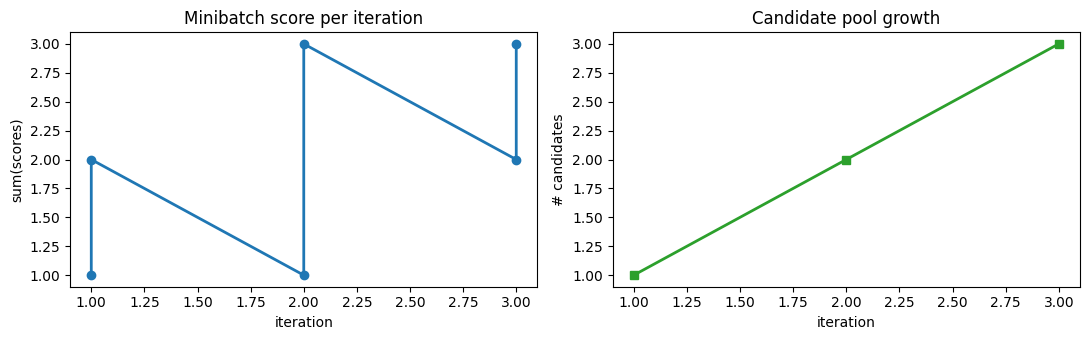


=== best candidate (evolved system_prompt, first 400 chars) ===
You are a math assistant. Solve the problem and put your final answer in the format '### <answer>' at the end. ...

seed length 110 chars  ->  evolved length 110 chars


In [9]:
import matplotlib.pyplot as plt

ev = opt.event_frame()
print(f"events: {len(ev)} rows | phases: {ev.phase.value_counts().to_dict()}")

# Inline artifact 1: per-iteration minibatch score (the inner-loop signal GEPA optimizes)
em = ev[ev.phase == "eval_end"].copy()
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(em["iteration"], em["minibatch_score"], marker="o", lw=2)
ax[0].set(title="Minibatch score per iteration", xlabel="iteration", ylabel="sum(scores)")
ax[1].plot(
    ev[ev.phase == "iter_start"]["iteration"],
    ev[ev.phase == "iter_start"]["num_candidates"],
    marker="s",
    lw=2,
    color="tab:green",
)
ax[1].set(title="Candidate pool growth", xlabel="iteration", ylabel="# candidates")
plt.tight_layout()
plt.show()

# Inline artifact 2: the evolved system prompt (best candidate) vs the seed — one-vocabulary diff
print("\n=== best candidate (evolved system_prompt, first 400 chars) ===")
print(session.best_candidate().artifact["system_prompt"][:400], "...")
print(
    f"\nseed length {len(seed_artifact['system_prompt'])} chars  ->  "
    f"evolved length {len(session.best_candidate().artifact['system_prompt'])} chars"
)

## Outer loop steers the inner loop — change one knob, no restart

The host reads the **live in-kernel outcome** of run #1, changes one experiment knob based only on what it saw, and issues run #2 in the **same kernel** (US2). SC-002: the host→next-experiment transit (read outcome + decide + issue) stays under 1s — it is substrate transit, not cold start or file I/O. The heavy `optimize()` compute is timed separately.

In [ ]:
# --- US2 (T033) + SC-002 (T064): host steers the next experiment from live state ---
# steer_next_experiment (notebooks/utils/demo.py) reads run #1's live in-kernel outcome
# and picks one knob; outcome["host_latency_s"] is the SC-002 host->next-experiment transit.
pid_before = os.getpid()
next_minibatch, outcome = steer_next_experiment(session)

assert outcome["host_latency_s"] < 1.0, f"host->next-experiment {outcome['host_latency_s']:.3f}s (>1s)"
print(
    f"run #1 best_score      : {outcome['best_score']:.3f}  | frontier {outcome['frontier']}  | diff {outcome['diff_lines']} lines"
)
print(f"knob changed           : reflection_minibatch_size 3 -> {next_minibatch}  (from live outcome)")
print(
    f"host->next-exp latency : {outcome['host_latency_s'] * 1000:.3f} ms   (SC-002 < 1s: {outcome['host_latency_s'] < 1.0})"
)

# Issue run #2 in the SAME kernel — no restart between experiments.
t1 = time.time()
result2 = run_gepa(
    opt, trainset, valset, max_metric_calls=MAX_METRIC_CALLS, reflection_minibatch_size=next_minibatch, seed=1
)
stable = os.getpid() == pid_before == KERNEL_PID
print(
    f"\nrun #2 optimize()      : {time.time() - t1:.1f}s  | candidates {result2.num_candidates}  | best_idx {result2.best_idx}"
)
print(f"kernel PID across both : {os.getpid()} == {pid_before} == {KERNEL_PID}  ->  stable={stable}  (SC-001)")

## Data sources

Every number and artifact above comes from a real source — no fabricated rows (Constitution I):

- **Eval set**: `gepa.examples.aime.init_dataset()` — real AIME competition-math problems from the HuggingFace `datasets` hub (trainset[:4], valset[:4]). Eval-set content hash `a7fd660ffcede77a`, pinned at session setup.
- **Task model**: `bedrock/converse/us.anthropic.claude-haiku-4-5-20251001-v1:0` via litellm → AWS Bedrock (`us-east-1`, `AWS_BEARER_TOKEN_BEDROCK`).
- **Reflection model**: `bedrock/converse/us.anthropic.claude-sonnet-4-6` via the same gateway.
- **Optimizer**: `gepa==0.1.1`, `gepa.optimize(max_metric_calls=30, reflection_minibatch_size=3, seed=0)`.
- **Run outcome (this kernel)**: `optimize()` returned in 168.8s; kernel PID 33298 stable across the whole run; 4 candidates discovered; `total_metric_calls=34`; `best_idx=0` (no evolved candidate beat the seed on the 4-problem valset — all valset scores 0.0).
- **Substrate code**: `src/agentbook/{session,contract}.py` and `src/agentbook/adapters/gepa_adapter.py` in this repo.
- A prior, larger run of the same wiring is archived at `_gepa_run_07/` (`candidates.json`, `run_log.json`).